## In last notebook we join the dataest and also that we see a EDA but the we downsmaple the dataset because of out machine limitation. Now we will do the Proper EDA and Then we will do Perprocessing and then after that we will train our ML Models

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
spark = SparkSession.builder \
.appName("Amazon Product Bestseller Churn") \
.getOrCreate()

spark.sparkContext.setLogLevel("WARN")

In [ ]:
"""Adding Different important Libraries require for the project"""
from pyspark.sql.functions import col, count, when
from pyspark.sql.functions import col, countDistinct
from pyspark.sql.functions import col, round, when
from pyspark.sql.functions import avg
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import builtins  # to access Python's built-in abs
from pyspark.sql.types import NumericType

In [3]:
path = r"balanced_df.csv"

Amazon_DF = spark.read.csv(
    path,
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"',
    quote='"'
)

print(f"Rows: {Amazon_DF.count()}, Columns: {len(Amazon_DF.columns)}")

print("Amazon Dataset")
Amazon_DF.printSchema()

Amazon_DF.show(10)


Rows: 25742, Columns: 13
Amazon Dataset
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- reviews: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- listPrice: double (nullable = true)
 |-- category_id: integer (nullable = true)
 |-- isBestSeller: integer (nullable = true)
 |-- boughtInLastMonth: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- savings_pct: double (nullable = true)
 |-- is_high_discount: integer (nullable = true)
 |-- is_highly_rated: integer (nullable = true)

+----------+--------------------+-----+-------+-----+---------+-----------+------------+-----------------+--------------+-----------+----------------+---------------+
|      asin|               title|stars|reviews|price|listPrice|category_id|isBestSeller|boughtInLastMonth| category_name|savings_pct|is_high_discount|is_highly_rated|
+----------+--------------------+-----+-------+-----+---------+-----

In [6]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

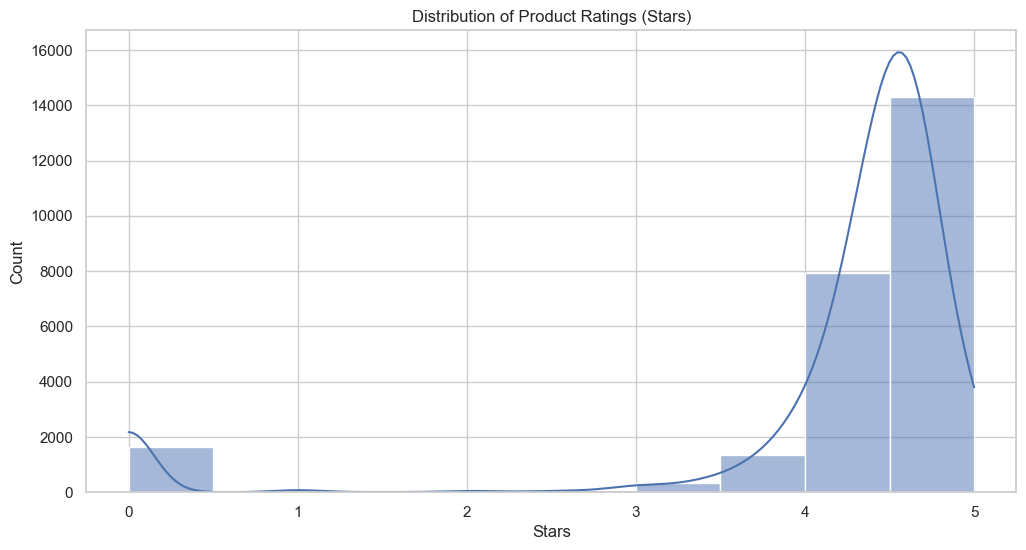

In [8]:
df_pd = Amazon_DF.toPandas()

sns.histplot(df_pd["stars"], bins=10, kde=True)
plt.title("Distribution of Product Ratings (Stars)")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

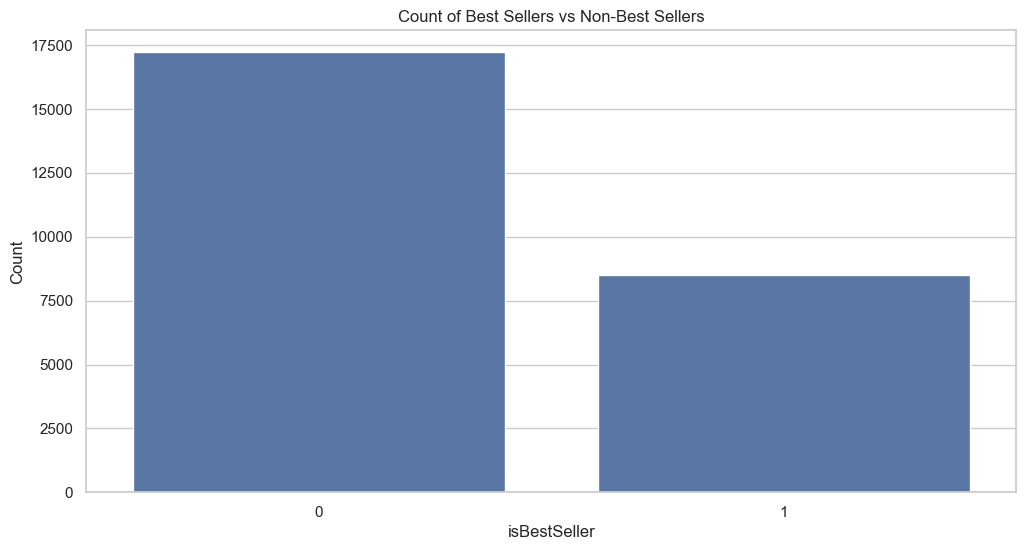

In [15]:
sns.countplot(x="isBestSeller", data=df_pd)
plt.title("Count of Best Sellers vs Non-Best Sellers")
plt.xlabel("isBestSeller")
plt.ylabel("Count")
plt.show()

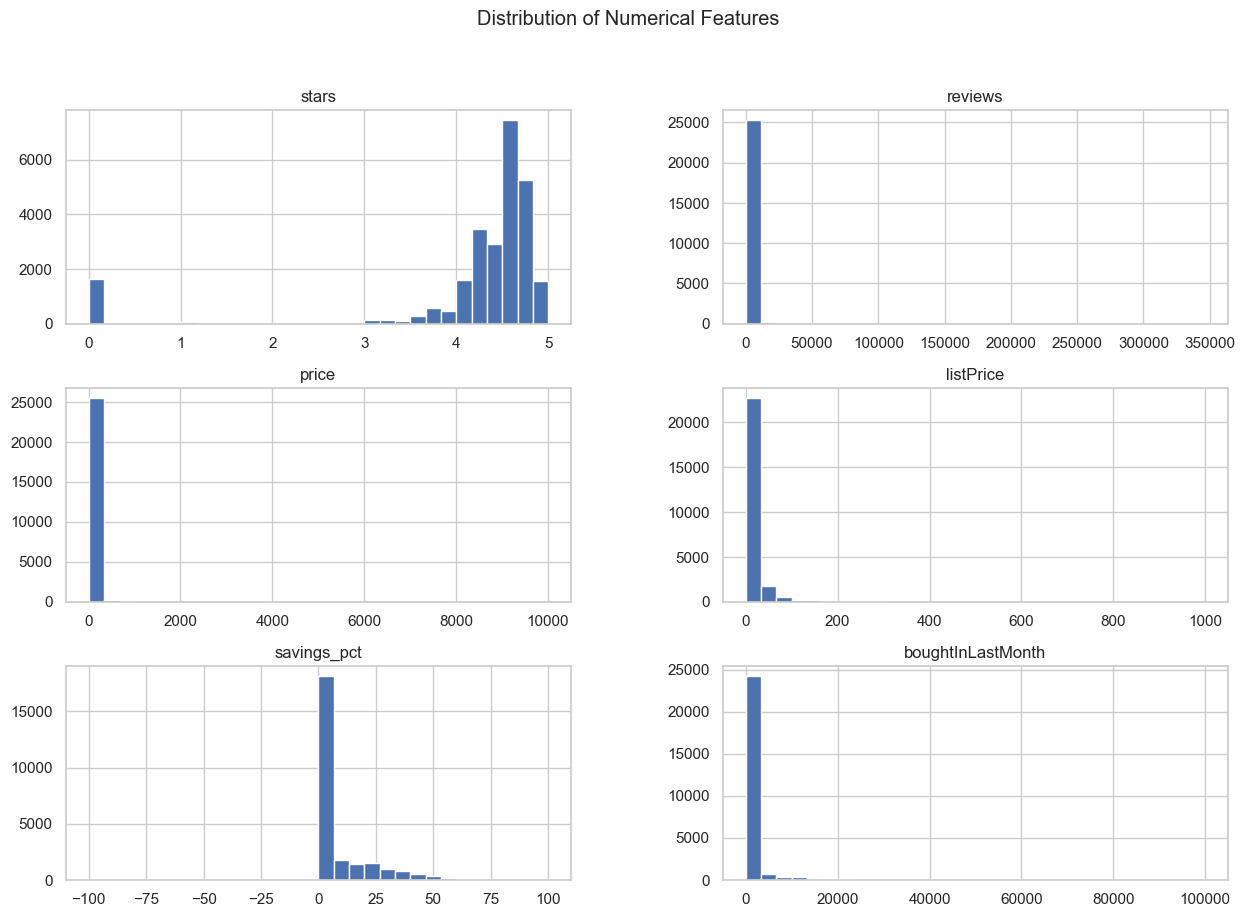

In [16]:
num_cols = ["stars", "reviews", "price", "listPrice", "savings_pct", "boughtInLastMonth"]

# Histograms
df_pd[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

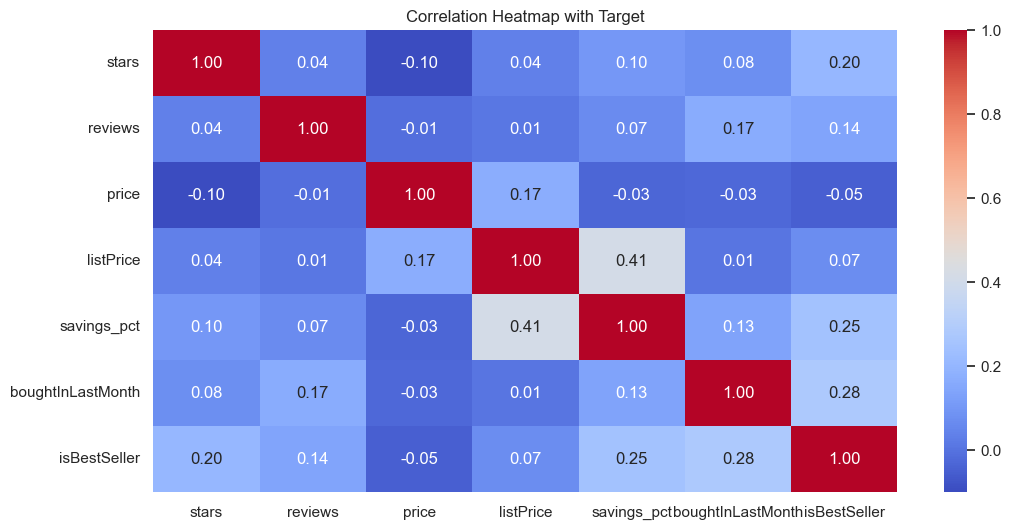

In [17]:
corr = df_pd[num_cols + ["isBestSeller"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap with Target")
plt.show()

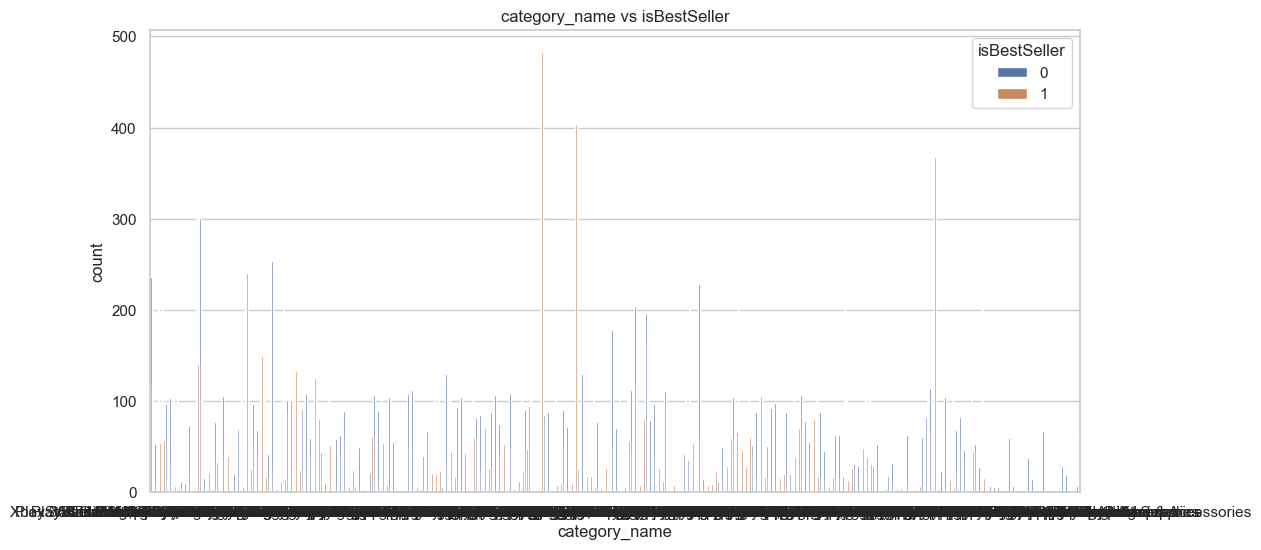

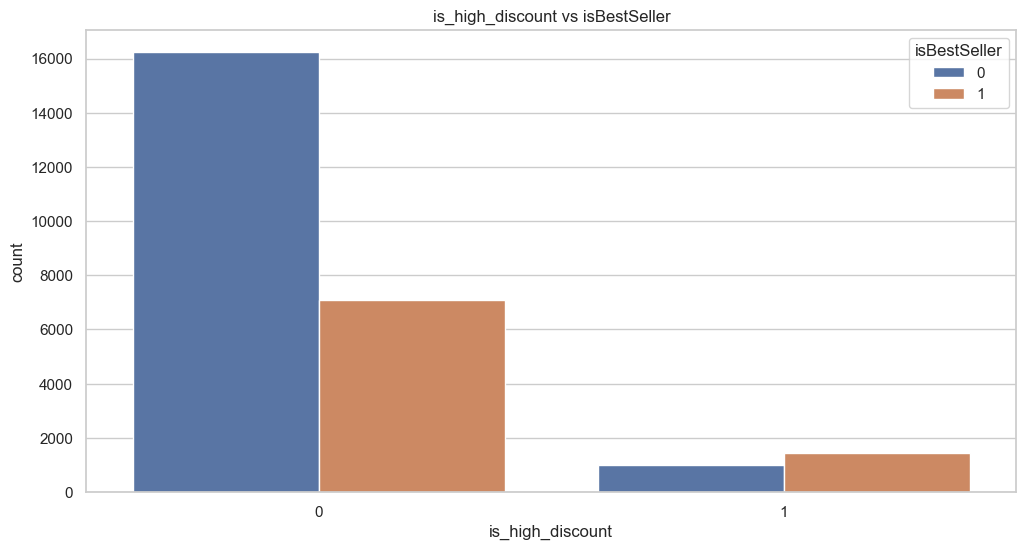

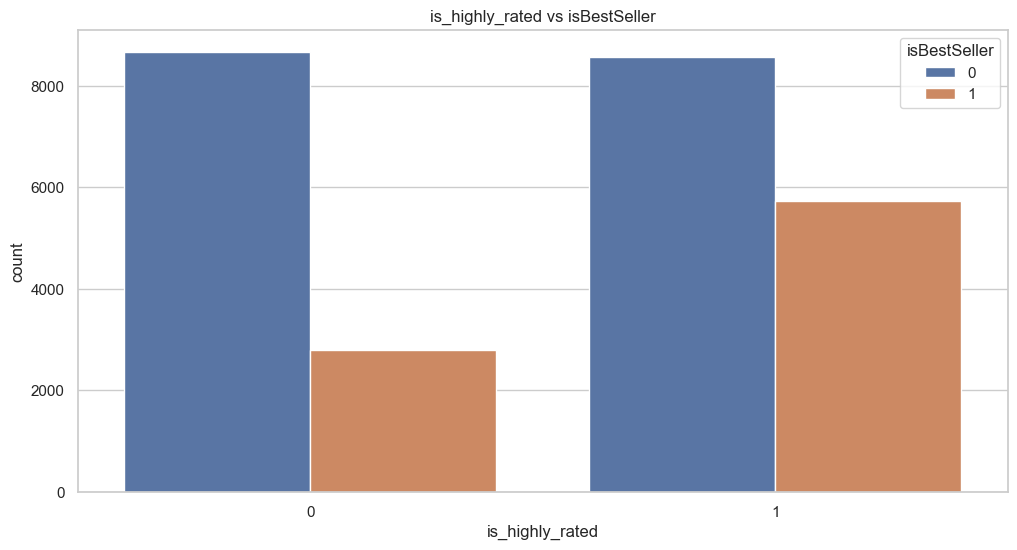

In [19]:
cat_cols = ["category_name", "is_high_discount", "is_highly_rated"]

# Countplots for categorical features
for col in cat_cols:
    sns.countplot(x=col, hue="isBestSeller", data=df_pd)
    plt.title(f"{col} vs isBestSeller")
    plt.show()

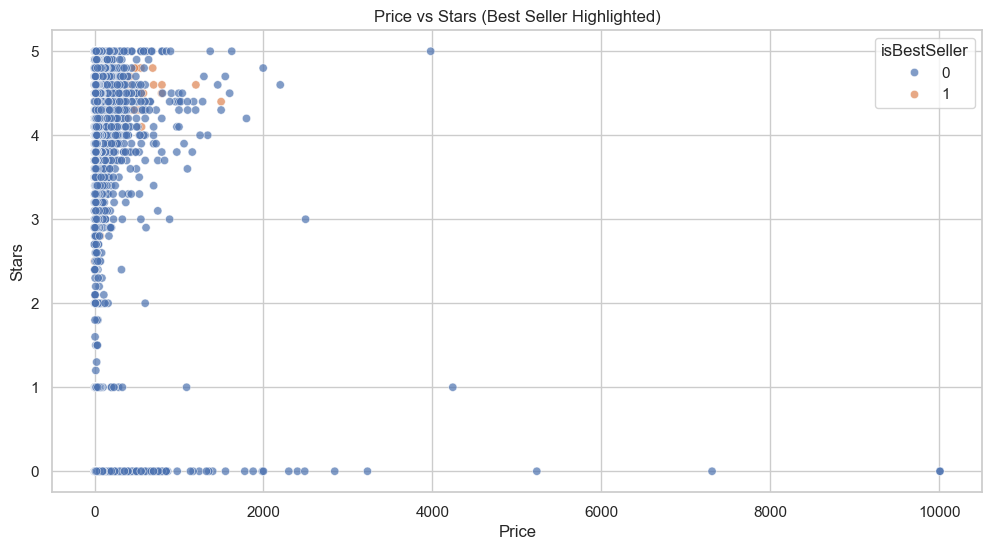

In [20]:
sns.scatterplot(data=df_pd, x="price", y="stars", hue="isBestSeller", alpha=0.7)
plt.title("Price vs Stars (Best Seller Highlighted)")
plt.xlabel("Price")
plt.ylabel("Stars")
plt.show()

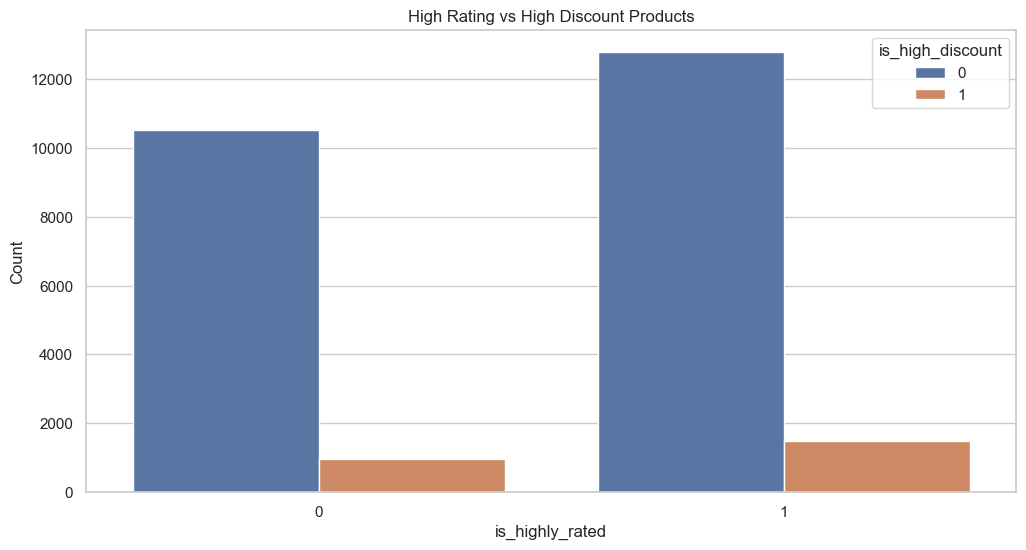

In [21]:
sns.countplot(x="is_highly_rated", hue="is_high_discount", data=df_pd)
plt.title("High Rating vs High Discount Products")
plt.xlabel("is_highly_rated")
plt.ylabel("Count")
plt.show()

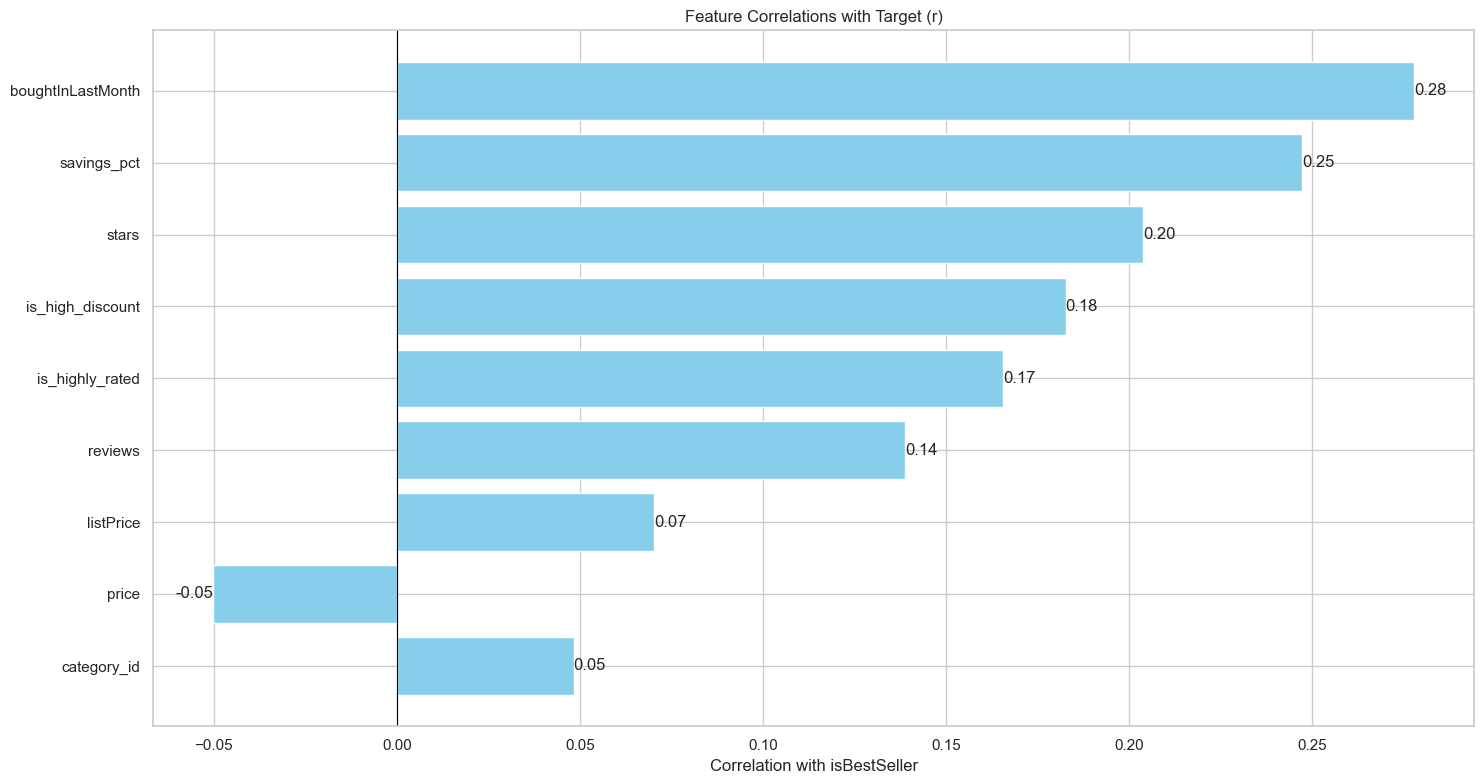

In [ ]:

target_col = "isBestSeller"

# Collect numeric columns properly
numeric_cols = [f.name for f in Amazon_DF.schema.fields if isinstance(f.dataType, NumericType)]

# Remove target itself from the list
feature_cols = [c for c in numeric_cols if c != target_col]

# Compute correlations and store them
correlations = []
for c in feature_cols:
    corr_value = Amazon_DF.stat.corr(c, target_col)
    if corr_value is not None and not np.isnan(corr_value):
        correlations.append((c, float(corr_value)))  # ensure plain float

# If no correlations found, stop
if not correlations:
    print("No numeric correlations could be computed.")
else:
    # Sort by absolute correlation using Python's built-in abs
    correlations.sort(key=lambda x: builtins.abs(x[1]), reverse=True)

    # Prepare data for plotting
    features = [f[0] for f in correlations]
    values = [f[1] for f in correlations]

    # Plot
    plt.figure(figsize=(15, 8))
    bars = plt.barh(features[::-1], values[::-1], color="skyblue")  # reverse for top-down order
    plt.xlabel(f"Correlation with {target_col}")
    plt.title("Feature Correlations with Target (r)")
    plt.axvline(0, color="black", linewidth=0.8)

    # Add labels to bars
    for bar, val in zip(bars, values[::-1]):
        plt.text(val, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va='center', ha='left' if val > 0 else 'right')

    plt.tight_layout()
    plt.show()


### Above Graph show which feature is more related with our target variable

In [26]:
# See unique values in the Best Seller column
print("Unique values in isBestSeller:")
Amazon_DF.select("isBestSeller").distinct().show()

print("Sample of Unique Category IDs:")
Amazon_DF.select("category_id").distinct().limit(10).show()

print("Sample of Unique stars:")
Amazon_DF.select("stars").distinct().limit(10).show()

Unique values in isBestSeller:
+------------+
|isBestSeller|
+------------+
|           1|
|           0|
+------------+

Sample of Unique Category IDs:
+-----------+
|category_id|
+-----------+
|        148|
|        243|
|         31|
|        251|
|        137|
|         65|
|         53|
|        255|
|        133|
|         78|
+-----------+

Sample of Unique stars:
+-----+
|stars|
+-----+
|  2.4|
|  0.0|
|  3.5|
|  2.9|
|  3.7|
|  2.3|
|  4.9|
|  3.1|
|  4.1|
|  4.2|
+-----+



### As we have clean data now with additional feathure and there is no duplicate and null fields in our dataset, that shows us our data is ready to Split into train and test. Then we will do our Model training on it in the next notebook 